In [1]:
import pandas as pd
from src.assay_calibration.data_utils.dataset import Scoreset
from src.assay_calibration.fit_utils.two_sample import density_utils
from tqdm.auto import tqdm
import sys
sys.path.append("..")
from src.assay_calibration.fit_utils.fit import (Fit,calculate_score_ranges, thresholds_from_prior)
from pathlib import Path
import numpy as np
import logging
import json
import pickle
from joblib import Parallel, delayed
pd.set_option("display.max_columns",None)
logging.getLogger('matplotlib').setLevel(logging.ERROR)

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("/data/dzeiberg/pillar_project/pillar_project_data/dataset_09192025/final_pillar_data_with_clinvar_gnomad_wREVEL_wAM_wspliceAI_wMutpred2_wtrainvar_expanded_091125.csv.tar.gz")

/tmp/ipykernel_1783792/3112519961.py:1: DtypeWarning: Columns (4,11,22,23,24,31,35,36,37,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,57,69,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/data/dzeiberg/pillar_project/pillar_project_data/dataset_09192025/final_pillar_data_with_clinvar_gnomad_wREVEL_wAM_wspliceAI_wMutpred2_wtrainvar_expanded_091125.csv.tar.gz")


- all variants
- all nsSNV
- all missense nsSNV
- all gnomAD
- all gnomAD nsSNV
- all gnomAD missense nsSNV

In [3]:
ddx3x_df = df[df.Dataset == "DDX3X_Radford_2023_cLFC_day15"]
ddx3x_scoresets = {population_type : Scoreset(ddx3x_df,
                                              population_type=population_type) for population_type in tqdm(['all_variants',
                                                                                                       'all_nsSNV',
                                                                                                       'all_missense_nsSNV',
                                                                                                       'gnomAD',
                                                                                                       'gnomAD_nsSNV',
                                                                                                       'gnomAD_missense_nsSNV'])}

  0%|          | 0/6 [00:00<?, ?it/s]

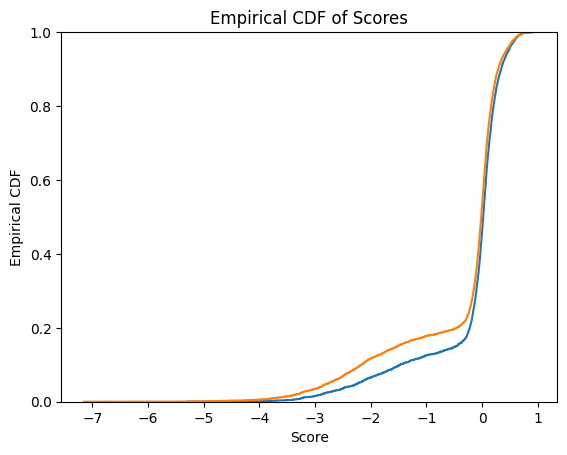

In [6]:
scores = ddx3x_scoresets['all_missense_nsSNV'].scores[ddx3x_scoresets['all_missense_nsSNV'].sample_assignments[:,2]]
allscores = ddx3x_scoresets['all_variants'].scores[ddx3x_scoresets['all_variants'].sample_assignments[:,2]]
sns.ecdfplot(scores)
sns.ecdfplot(allscores)
plt.xlabel("Score")
plt.ylabel("Empirical CDF")
plt.title("Empirical CDF of Scores")
plt.show()

In [4]:
# # Generate jobs 
# N_restarts=100
# num_bootstrap_iters=10
# jobs = []
# for population_name, scoreset in ddx3x_scoresets.items():
#     fit = Fit(scoreset)
#     save_dir = Path("test") / "test_fits" / scoreset.scoreset_name / population_name
#     if save_dir.exists() and any(save_dir.iterdir()):
#         for file in save_dir.iterdir():
#             file.unlink()
#     save_dir.mkdir(exist_ok=True,parents=True)
#     scoreset_jobs = sum([fit.generate_fit_jobs([2,3],
#                                     save_dir,
#                                     bootstrap_seed=fit_num,
#                                     num_fits=N_restarts) \
#                     for fit_num in range(num_bootstrap_iters)],[])
#     jobs += scoreset_jobs

# # Write jobs to file
# job_savedir = Path("test/test_jobs/")
# job_savedir.mkdir(parents=True,exist_ok=True)
# Parallel(n_jobs=-1, verbose=100)(
#     delayed(lambda jobNum, job: pickle.dump(job, open(job_savedir / f"job_{jobNum}.pkl", "wb")))(jobNum, job)
#     for jobNum, job in enumerate(jobs)
# )

In [5]:
# Parallel(n_jobs=-1,verbose=100)(delayed(Fit.execute_fit_job)(job) for job in jobs)

In [6]:


fits_dir = Path("test/test_fits/DDX3X_Radford_2023_cLFC_day15/")

def process_fit(population_type,fit_filepath):
    with open(fit_filepath) as f:
        fit = json.load(f)
    fit['fit']['weights'] = np.array(fit['fit']['weights'])
    return ((population_type,fit['bootstrap_seed']),fit)


processed_fits = Parallel(n_jobs=-1, verbose=100)(delayed(process_fit)(population_type, fit_file) \
                                                  for population_type in ddx3x_scoresets.keys() \
                                                    for fit_file in tqdm((fits_dir / population_type).glob("*.json")))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 128 concurrent workers.


0it [00:00, ?it/s]

[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.17872072601318362s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  15 task

0it [00:00, ?it/s]

[Parallel(n_jobs=-1)]: Done 1666 tasks      | elapsed:   21.5s
[Parallel(n_jobs=-1)]: Done 1667 tasks      | elapsed:   21.5s
[Parallel(n_jobs=-1)]: Done 1668 tasks      | elapsed:   21.5s
[Parallel(n_jobs=-1)]: Done 1669 tasks      | elapsed:   21.5s
[Parallel(n_jobs=-1)]: Done 1670 tasks      | elapsed:   21.5s
[Parallel(n_jobs=-1)]: Done 1671 tasks      | elapsed:   21.5s
[Parallel(n_jobs=-1)]: Done 1672 tasks      | elapsed:   21.5s
[Parallel(n_jobs=-1)]: Done 1673 tasks      | elapsed:   21.5s
[Parallel(n_jobs=-1)]: Done 1674 tasks      | elapsed:   21.5s
[Parallel(n_jobs=-1)]: Done 1675 tasks      | elapsed:   21.5s
[Parallel(n_jobs=-1)]: Done 1676 tasks      | elapsed:   21.5s
[Parallel(n_jobs=-1)]: Done 1677 tasks      | elapsed:   21.5s
[Parallel(n_jobs=-1)]: Done 1678 tasks      | elapsed:   24.9s
[Parallel(n_jobs=-1)]: Done 1679 tasks      | elapsed:   24.9s
[Parallel(n_jobs=-1)]: Done 1680 tasks      | elapsed:   24.9s
[Parallel(n_jobs=-1)]: Done 1681 tasks      | elapsed: 

...

[Parallel(n_jobs=-1)]: Done 5634 tasks      | elapsed:   42.5s
[Parallel(n_jobs=-1)]: Done 5635 tasks      | elapsed:   42.5s
[Parallel(n_jobs=-1)]: Done 5636 tasks      | elapsed:   42.5s
[Parallel(n_jobs=-1)]: Done 5637 tasks      | elapsed:   42.5s
[Parallel(n_jobs=-1)]: Done 5638 tasks      | elapsed:   42.5s
[Parallel(n_jobs=-1)]: Done 5639 tasks      | elapsed:   42.5s
[Parallel(n_jobs=-1)]: Done 5640 tasks      | elapsed:   42.5s
[Parallel(n_jobs=-1)]: Done 5641 tasks      | elapsed:   42.5s
[Parallel(n_jobs=-1)]: Done 5642 tasks      | elapsed:   42.5s
[Parallel(n_jobs=-1)]: Done 5643 tasks      | elapsed:   42.5s
[Parallel(n_jobs=-1)]: Done 5644 tasks      | elapsed:   42.5s
[Parallel(n_jobs=-1)]: Done 5645 tasks      | elapsed:   42.5s
[Parallel(n_jobs=-1)]: Done 5646 tasks      | elapsed:   42.5s
[Parallel(n_jobs=-1)]: Done 5647 tasks      | elapsed:   42.5s
[Parallel(n_jobs=-1)]: Done 5648 tasks      | elapsed:   42.5s
[Parallel(n_jobs=-1)]: Done 5649 tasks      | elapsed: 

0it [00:00, ?it/s]

[Parallel(n_jobs=-1)]: Done 7682 tasks      | elapsed:   53.5s
[Parallel(n_jobs=-1)]: Done 7683 tasks      | elapsed:   53.5s
[Parallel(n_jobs=-1)]: Done 7684 tasks      | elapsed:   53.5s
[Parallel(n_jobs=-1)]: Done 7685 tasks      | elapsed:   53.5s
[Parallel(n_jobs=-1)]: Done 7686 tasks      | elapsed:   53.5s
[Parallel(n_jobs=-1)]: Done 7687 tasks      | elapsed:   53.5s
[Parallel(n_jobs=-1)]: Done 7688 tasks      | elapsed:   53.5s
[Parallel(n_jobs=-1)]: Done 7689 tasks      | elapsed:   53.5s
[Parallel(n_jobs=-1)]: Done 7690 tasks      | elapsed:   53.5s
[Parallel(n_jobs=-1)]: Done 7691 tasks      | elapsed:   53.5s
[Parallel(n_jobs=-1)]: Done 7692 tasks      | elapsed:   53.5s
[Parallel(n_jobs=-1)]: Done 7693 tasks      | elapsed:   53.5s
[Parallel(n_jobs=-1)]: Done 7694 tasks      | elapsed:   53.5s
[Parallel(n_jobs=-1)]: Done 7695 tasks      | elapsed:   53.5s
[Parallel(n_jobs=-1)]: Done 7696 tasks      | elapsed:   53.5s
[Parallel(n_jobs=-1)]: Done 7697 tasks      | elapsed: 

0it [00:00, ?it/s]

[Parallel(n_jobs=-1)]: Done 9730 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 9731 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 9732 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 9733 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 9734 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 9735 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 9736 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 9737 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 9738 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 9739 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 9740 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 9741 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 9742 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 9743 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 9744 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 9745 tasks      | elapsed: 

In [7]:
sorted_processed_fits = sorted(processed_fits, key=lambda tup: -tup[1]['val_ll']) # type: ignore
scoreset_fits = {population_type: dict() for population_type in ddx3x_scoresets.keys()}
for (population_type, bootstrap_index), fit in sorted_processed_fits:
    if bootstrap_index not in scoreset_fits[population_type]:
        scoreset_fits[population_type][bootstrap_index] = fit
scoreset_fits = {k : list(d.values()) for k,d in scoreset_fits.items()}


In [8]:
len(scoreset_fits['all_variants'])

10

In [9]:
def tryToGetPrior(fit,population_name):
    scoreset = ddx3x_scoresets[population_name]
    scores = scoreset.scores
    sample_assignment = scoreset.sample_assignments
    population_sample = scores[sample_assignment[:,2]]
    try:
        prior = Fit.from_dict(scoreset,fit['fit']).get_prior_estimate(population_sample,
                                                         tolerance=1e-5)
    except ValueError as e:
        print(e)
        prior = np.nan
    return prior

In [10]:
population_priors = {population_name: [tryToGetPrior(fit,population_name) for fit in tqdm(population_fits,leave=False)] \
                        for population_name,population_fits in tqdm(scoreset_fits.items())}

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
figdims = np.array([ddx3x_scoresets['gnomAD'].sample_assignments.shape[1],
                    len(ddx3x_scoresets)])
fig,ax = plt.subplots(*figdims, figsize=np.array((5,3)) * figdims,sharex=True,sharey='row')

for scoresetNum,((population_type,scoreset),scoresetAx) in enumerate(zip(ddx3x_scoresets.items(),
                                                                         ax.T)):
    scoreset_fit = scoreset_fits[population_type]
    for i,(sample_scores, sample_name) in enumerate(scoreset.samples):
        score_range = np.linspace(sample_scores.min(),sample_scores.max(),1000)
        sns.histplot(sample_scores, ax=scoresetAx[i],stat='density',label=f"n={len(sample_scores):,d}")
        scoresetAx[i].set_title(sample_name.replace("population",scoreset.population_type))
        pdf = np.stack([density_utils.joint_densities(score_range,
                                            fit['fit']['component_params'],
                                            fit['fit']['weights'][i]).sum(0) for fit in scoreset_fit])
        
        scoresetAx[i].plot(score_range, np.median(pdf,axis=0),color='C1')
        scoresetAx[i].legend()
        scoresetAx[i].fill_between(score_range, *np.percentile(pdf,[2.5,97.5],axis=0),color='C1',alpha=.5)
    population_idx = [i for i,name in enumerate(scoreset.sample_names) if name in {'population',population_type}][0]
    scoresetAx[population_idx].set_title(f"{scoreset.population_type}\nprior: {np.median(population_priors[population_type]):.3f}")
save_dir = Path("test/figures/")
save_dir.mkdir(exist_ok=True)
fig.savefig(save_dir / "ddx3_distributions.png",dpi=300)

In [11]:
population_point_score_ranges = {}
population_log_lrPlus = {}
for population_type,scoreset in ddx3x_scoresets.items():
    score_range = np.linspace(*np.percentile(scoreset.scores,[0,100]),10000) # type: ignore
    fP = np.stack([density_utils.joint_densities(score_range,_fit['fit']['component_params'],_fit['fit']['weights'][0]).sum(0) \
                for _fit in scoreset_fits[population_type]])
    fB = np.stack([density_utils.joint_densities(score_range,_fit['fit']['component_params'],_fit['fit']['weights'][1]).sum(0) \
                for _fit in scoreset_fits[population_type]])
    log_fp = np.stack([density_utils.mixture_pdf(score_range, _fit['fit']['component_params'],_fit['fit']['weights'][0])
                    for _fit in scoreset_fits[population_type]])
    log_fb = np.stack([density_utils.mixture_pdf(score_range, _fit['fit']['component_params'],_fit['fit']['weights'][1])
                    for _fit in scoreset_fits[population_type]])
    log_lr_plus = log_fp - log_fb
    score_ranges_pathogenic, score_ranges_benign = calculate_score_ranges(np.percentile(log_lr_plus,5,axis=0),
                                                                          np.percentile(log_lr_plus,95,axis=0),
                                                                          np.median(population_priors[population_type]),
                                                                          score_range,
                                                                          [1,2,3,4,8],)
    population_point_score_ranges[population_type] = {**score_ranges_pathogenic,
                                                      **score_ranges_benign}
    population_log_lrPlus[population_type] = {"scores":score_range,"log_lr":log_lr_plus}

0.94625901
[(-8, np.float64(nan)), (-4, np.float64(nan)), (-3, np.float64(nan)), (-2, np.float64(-0.1602000972297235)), (-1, np.float64(-0.21852005017301757))]
[(-8, np.float64(nan)), (-4, np.float64(nan)), (-3, np.float64(nan)), (-2, np.float64(0.13949966095109456)), (-1, np.float64(0.20429960866586594))]
-0.19746006716571696
0.94625901
[(-8, np.float64(nan)), (-4, np.float64(nan)), (-3, np.float64(-0.21204005540154114)), (-2, np.float64(-0.23877003383388384)), (-1, np.float64(-0.25983001684118445))]
[(-8, np.float64(nan)), (-4, np.float64(nan)), (-3, np.float64(0.10466968905440499)), (-2, np.float64(0.16865963742274204)), (-1, np.float64(0.22535959167316655))]
0.94625901
[(-8, np.float64(nan)), (-4, np.float64(nan)), (-3, np.float64(-0.20394006193719427)), (-2, np.float64(-0.222570046905191)), (-1, np.float64(-0.24201003121962295))]
[(-8, np.float64(nan)), (-4, np.float64(nan)), (-3, np.float64(0.15083965180117964)), (-2, np.float64(0.20429960866586594)), (-1, np.float64(0.2634295609

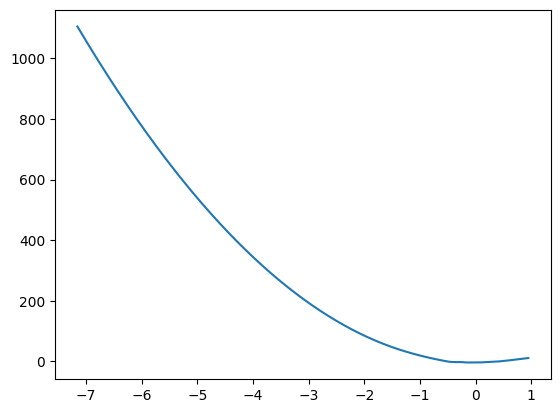

In [14]:
plt.plot(population_log_lrPlus['all_variants']['scores'],
         np.percentile(population_log_lrPlus['all_variants']['log_lr'],.5,axis=0))

{8: [(-7.152924455, -0.6850796737193727), (0.7291791851555152, 0.94625901)],
 4: [(-0.6850796737193727, -0.602459740383039),
  (0.5809493047579748, 0.7291791851555152)],
 3: [(-0.602459740383039, -0.5732997639113915),
  (0.5282993472397237, 0.5809493047579748)],
 2: [(-0.5732997639113915, -0.5587197756755682),
  (0.5007593694609458, 0.5282993472397237)],
 1: [(-0.5587197756755682, -0.5352297946289637),
  (0.4586394034463437, 0.5007593694609458)],
 -2: [(-0.1602000972297235, -0.07110016912191242),
  (-0.07110016912191242, 0.13949966095109456)],
 -1: [(-0.21852005017301757, -0.1602000972297235),
  (0.13949966095109456, 0.20429960866586594)]}

In [ ]:
from typing import Dict, List, Tuple
def assign_points(scores, point_score_ranges: Dict[int, List[Tuple[float,float]]]):
    """
    Assign points to each score based on the thresholds

    Required Arguments:
    --------------------------------
    scores -- np.ndarray (n,)
        The scores to assign points to

    point_score_ranges -- Dict[int, List[Tuple[float,float]]]
        The score ranges for evidence points
    """
    
    points = np.zeros_like(scores, dtype=int)
    for points_key, score_ranges in point_score_ranges.items():
        for score_range in score_ranges:
            mask = (scores >= score_range[0]) & \
                    (scores <= score_range[1])
            points[mask] = points_key
    return points

In [ ]:
def get_point_distribution(point_assignment, sample_assignment,sample_names):
    sample_point_distrs = {}
    for sample_idx, sample_name in enumerate(sample_names):
        sample_mask = np.where(sample_assignment[:,sample_idx])[0]
        sample_points = point_assignment[sample_mask]
        sample_point_distrs[sample_name] = dict(zip(*np.unique(sample_points,return_counts=True)))
    return sample_point_distrs

In [ ]:
save_dir = Path("test/figures")
save_dir.mkdir(exist_ok=True)
point_values = [-8,-4,-3,-2,-1,1,2,3,4,8]
sample_point_dfs = {}
for sample_name in ddx3x_scoresets.keys():
    point_assignments = assign_points(ddx3x_scoresets[sample_name].scores,
                                      population_point_score_ranges[sample_name])
    _point_distr = get_point_distribution(point_assignments,
                                          ddx3x_scoresets[sample_name].sample_assignments,
                                          ddx3x_scoresets[sample_name].sample_names)
    _point_distr[sample_name] = _point_distr.pop("population")
    _point_df = pd.DataFrame.from_dict(_point_distr,orient='index')
    for p in point_values:
        if p not in _point_df.columns:
            _point_df[p] = 0
    _point_df = _point_df.loc[:,point_values]
    _point_df = _point_df.div(_point_df.sum(axis=1), axis=0).fillna(0)
    sample_point_dfs[sample_name] = _point_df
    fig, ax = plt.subplots(1,1,figsize=(12,5))
    sns.heatmap(data=_point_df, cmap="crest", vmin=0, vmax=1, annot=True, fmt=".2%", ax=ax)
    fig.savefig(save_dir / f"point_distribution_{sample_name}.png",
                dpi=300)


In [ ]:
sample_point_dfs['all_variants'].index

In [ ]:
plp_df = pd.DataFrame([df.loc['Pathogenic/Likely Pathogenic'] for df in sample_point_dfs.values()],
                      index=[sampleName for sampleName in sample_point_dfs.keys()])

blb_df = pd.DataFrame([df.loc['Benign/Likely Benign'] for df in sample_point_dfs.values()],
                      index=[sampleName for sampleName in sample_point_dfs.keys()])


In [ ]:
blb_df = blb_df.loc[:,[c for c in blb_df.columns if (c < 0) or (blb_df[c].sum() > 0)]]
plp_df = plp_df.loc[:,[c for c in plp_df.columns if (c > 0) or (plp_df[c].sum() > 0)]]

In [ ]:
ax = plp_df.iloc[:,::-1].plot(kind='barh', stacked=True, colormap='coolwarm_r')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_yticklabels([f"{sample_name.replace('_',' ')}\nprior: {np.median(population_priors[sample_name]):.3f}"\
                    for sample_name in plp_df.index])
ax.set_xlabel("Fraction of Variants")
ax.set_title("Pathogenic/Likely pathogenic point distribution")
ax.set_ylabel("Population")

In [ ]:
from matplotlib.colors import ListedColormap

# Create a discrete color map with 6 colors
discrete_cmap = ListedColormap(sns.color_palette("Blues_r", n_colors=6))

# Access a specific color from the discrete color map
color = discrete_cmap(p)

In [ ]:
color

In [ ]:
ax = blb_df.plot(kind='barh', stacked=True, colormap=discrete_cmap)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_yticklabels([f"{sample_name.replace('_',' ')}\nprior: {np.median(population_priors[sample_name]):.3f}"\
                    for sample_name in blb_df.index])
ax.set_xlabel("Fraction of Variants")
ax.set_title("Benign/Likely benign point distribution")
ax.set_ylabel("Population")